# Notebook 05-CIC — SHAP Stability on CIC-IDS2017

**Project:** Calibrated and Stability-Aware Explainable Intrusion Detection
**Author:** Md Anas Biswas, University of Portsmouth
**Dataset:** CIC-IDS2017 (200K subsample)

Same methodology as NSL-KDD Notebook 05 — three perturbation types, three stability metrics. Smaller sample size (1500) given CIC has fewer features (78 vs 122).

## Methodology

- **Sample size:** 1500 stratified eval samples
- **Perturbations:** Gaussian (ε=0.05), FGSM (ε=0.05, from DNN), PGD (ε=0.05, 10 steps, from DNN). Tree models receive transfer attacks.
- **Metrics:** Jaccard top-10, Lipschitz median, F-Fidelity

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(REPO)

for f in ['.gitconfig', '.git-credentials']:
    src = f'/content/drive/MyDrive/XIDS_Research/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'/root/{f}')
        if f == '.git-credentials':
            os.chmod(f'/root/{f}', 0o600)

!git pull
print(f'✓ Ready in: {os.getcwd()}')

Mounted at /content/drive
Already up to date.
✓ Ready in: /content/drive/MyDrive/XIDS_Research/xids-research


In [2]:
!pip install -q shap==0.47.2 2>&1 | tail -2
print('✓ SHAP ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.9 MB/s eta 0:00:00
✓ SHAP ready


In [3]:
import numpy as np
import pandas as pd
import json, pickle, time
from pathlib import Path

import shap
import xgboost as xgb
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type != 'cuda':
    print('⚠ No GPU detected. Please enable T4 GPU and re-run.')

Device: cuda


In [4]:
PROCESSED = Path(REPO) / 'data' / 'processed' / 'cic_ids2017'
MODELS_DIR = Path(REPO) / 'models' / 'cic_ids2017'
CALIB_DIR  = Path(REPO) / 'calibrators' / 'cic_ids2017'
SHAP_DIR   = Path(REPO) / 'shap_values' / 'cic_ids2017'
STAB_DIR   = SHAP_DIR / 'stability'
PERT_DIR   = STAB_DIR / 'perturbations'
PSHAP_DIR  = STAB_DIR / 'perturbed_shap'
FIG_DIR    = Path(REPO) / 'results' / 'figures'
TABLES_DIR = Path(REPO) / 'results' / 'tables'
for d in [STAB_DIR, PERT_DIR, PSHAP_DIR, FIG_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

X_train = np.load(PROCESSED / 'X_train.npy')
X_test  = np.load(PROCESSED / 'X_test.npy')
y_test_b = np.load(PROCESSED / 'y_test_binary.npy')
y_test_5 = np.load(PROCESSED / 'y_test_5class.npy')
idx_eval = np.load(CALIB_DIR / 'idx_eval.npy')
X_eval = X_test[idx_eval]
y_eval_b = y_test_b[idx_eval]
y_eval_5 = y_test_5[idx_eval]

with open(PROCESSED / 'feature_names.json') as f:
    FEATURE_NAMES = json.load(f)

print(f'X_eval: {X_eval.shape}')

X_eval: (20004, 78)


---
## Step 1 — Stability sample (1500 stratified)

In [5]:
STAB_SIZE = 1500
rng = np.random.RandomState(SEED)
indices = []
per_class = STAB_SIZE // 5
for c in range(5):
    pool = np.where(y_eval_5 == c)[0]
    n_take = min(per_class, len(pool))
    indices.extend(rng.choice(pool, n_take, replace=False).tolist())
indices = np.array(indices)
X_stab = X_eval[indices]
y_stab_b = y_eval_b[indices]
y_stab_5 = y_eval_5[indices]
np.save(STAB_DIR / 'stability_indices.npy', indices)
print(f'Stability sample: {X_stab.shape}')
print(f'Per class: {np.bincount(y_stab_5)}')

Stability sample: (1015, 78)
Per class: [300 300 300 112   3]


---
## Step 2 — Load models

In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(256, 128, 64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def load_model(name):
    pkl = MODELS_DIR / f'{name}.pkl'
    pt = MODELS_DIR / f'{name}.pt'
    if pkl.exists():
        with open(pkl, 'rb') as f:
            return ('sklearn', pickle.load(f))
    state = torch.load(pt, map_location=DEVICE, weights_only=False)
    m = MLP(state['in_dim'], state['n_classes'], hidden=tuple(state['hidden']), dropout=state['dropout']).to(DEVICE)
    m.load_state_dict(state['state_dict']); m.eval()
    return ('torch', m)

CANONICAL = {
    'rf_binary_cw':      {'target': 'binary', 'kind': 'tree'},
    'xgb_binary_cw':     {'target': 'binary', 'kind': 'tree'},
    'dnn_binary_cw':     {'target': 'binary', 'kind': 'dnn'},
    'rf_5class_smote':   {'target': '5class', 'kind': 'tree'},
    'xgb_5class_smote':  {'target': '5class', 'kind': 'tree'},
    'dnn_5class_smote':  {'target': '5class', 'kind': 'dnn'},
}

MODELS = {n: load_model(n) for n in CANONICAL}
for n in MODELS:
    print(f'  ✓ {n}')

  ✓ rf_binary_cw
  ✓ xgb_binary_cw
  ✓ dnn_binary_cw
  ✓ rf_5class_smote
  ✓ xgb_5class_smote
  ✓ dnn_5class_smote


---
## Step 3 — Perturbations

In [7]:
EPSILON = 0.05
ALPHA = 0.005
PGD_STEPS = 10

# Gaussian
rng = np.random.RandomState(SEED)
X_pert_gaussian_b = X_stab + rng.normal(0, EPSILON, X_stab.shape).astype(np.float32)
X_pert_gaussian_5 = X_stab + rng.normal(0, EPSILON, X_stab.shape).astype(np.float32)
np.save(PERT_DIR / 'gaussian_binary.npy', X_pert_gaussian_b)
np.save(PERT_DIR / 'gaussian_5class.npy', X_pert_gaussian_5)
print(f'✓ Gaussian: ‖δ‖_mean = {np.linalg.norm(X_pert_gaussian_b - X_stab, axis=1).mean():.3f}')

def fgsm_attack(model, X, y, eps):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32, requires_grad=True, device=DEVICE)
    y_t = torch.tensor(y, dtype=torch.long, device=DEVICE)
    logits = model(X_t)
    loss = F.cross_entropy(logits, y_t)
    grad = torch.autograd.grad(loss, X_t)[0]
    return (X_t + eps * grad.sign()).detach().cpu().numpy().astype(np.float32)

def pgd_attack(model, X, y, eps, alpha, steps):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    y_t = torch.tensor(y, dtype=torch.long, device=DEVICE)
    delta = torch.empty_like(X_t).uniform_(-eps, eps).to(DEVICE)
    X_adv = X_t + delta
    for _ in range(steps):
        X_adv = X_adv.detach().requires_grad_(True)
        logits = model(X_adv)
        loss = F.cross_entropy(logits, y_t)
        grad = torch.autograd.grad(loss, X_adv)[0]
        X_adv = X_adv + alpha * grad.sign()
        X_adv = torch.max(torch.min(X_adv, X_t + eps), X_t - eps)
    return X_adv.detach().cpu().numpy().astype(np.float32)

_, dnn_b = MODELS['dnn_binary_cw']
_, dnn_5 = MODELS['dnn_5class_smote']

print('\nGenerating FGSM...')
X_pert_fgsm_b = fgsm_attack(dnn_b, X_stab, y_stab_b, EPSILON)
X_pert_fgsm_5 = fgsm_attack(dnn_5, X_stab, y_stab_5, EPSILON)
np.save(PERT_DIR / 'fgsm_binary.npy', X_pert_fgsm_b)
np.save(PERT_DIR / 'fgsm_5class.npy', X_pert_fgsm_5)

print('Generating PGD...')
X_pert_pgd_b = pgd_attack(dnn_b, X_stab, y_stab_b, EPSILON, ALPHA, PGD_STEPS)
X_pert_pgd_5 = pgd_attack(dnn_5, X_stab, y_stab_5, EPSILON, ALPHA, PGD_STEPS)
np.save(PERT_DIR / 'pgd_binary.npy', X_pert_pgd_b)
np.save(PERT_DIR / 'pgd_5class.npy', X_pert_pgd_5)
print('✓ All perturbations generated')

✓ Gaussian: ‖δ‖_mean = 0.441

Generating FGSM...
Generating PGD...
✓ All perturbations generated


---
## Step 4 — Compute SHAP on stability sample + perturbed inputs

In [8]:
# Smaller background for speed
BG_SIZE = 200
y_train_5 = np.load(PROCESSED / 'y_train_5class.npy')
rng_bg = np.random.RandomState(SEED)
bg_idx = []
for c in range(5):
    pool = np.where(y_train_5 == c)[0]
    bg_idx.extend(rng_bg.choice(pool, min(BG_SIZE // 5, len(pool)), replace=False).tolist())
X_background = X_train[np.array(bg_idx)]
print(f'DNN background: {X_background.shape}')

def compute_shap(name, X_input):
    info = CANONICAL[name]
    kind, model = MODELS[name]
    t0 = time.time()
    if info['kind'] == 'tree':
        if name.startswith('xgb'):
            booster = model.get_booster()
            dmat = xgb.DMatrix(X_input)
            raw = booster.predict(dmat, pred_contribs=True)
            if raw.ndim == 2:
                arr = raw[:, :-1]
                arr = np.stack([-arr, arr], axis=-1)
            else:
                arr = raw[:, :, :-1]
                arr = np.transpose(arr, (0, 2, 1))
        else:
            explainer = shap.TreeExplainer(model)
            raw = explainer.shap_values(X_input)
            arr = np.stack(raw, axis=-1) if isinstance(raw, list) else np.asarray(raw)
    else:
        bg_t = torch.tensor(X_background, dtype=torch.float32).to(DEVICE)
        X_t = torch.tensor(X_input, dtype=torch.float32).to(DEVICE)
        explainer = shap.DeepExplainer(model, bg_t)
        raw = explainer.shap_values(X_t, check_additivity=False)
        arr = np.stack(raw, axis=-1) if isinstance(raw, list) else np.asarray(raw)
    print(f'    {name}: {arr.shape}  ({time.time()-t0:.1f}s)')
    return arr.astype(np.float32)

SHAP_ORIG = {}
print('\n=== Original SHAP on stability sample ===')
for name in CANONICAL:
    SHAP_ORIG[name] = compute_shap(name, X_stab)
    np.save(PSHAP_DIR / f'{name}_original.npy', SHAP_ORIG[name])

DNN background: (189, 78)

=== Original SHAP on stability sample ===
    rf_binary_cw: (1015, 78, 2)  (129.2s)
    xgb_binary_cw: (1015, 78, 2)  (0.7s)
    dnn_binary_cw: (1015, 78, 2)  (22.2s)
    rf_5class_smote: (1015, 78, 5)  (194.5s)
    xgb_5class_smote: (1015, 78, 5)  (2.5s)
    dnn_5class_smote: (1015, 78, 5)  (55.0s)


In [9]:
PERTURB_X = {
    'gaussian_binary':  X_pert_gaussian_b,
    'gaussian_5class':  X_pert_gaussian_5,
    'fgsm_binary':      X_pert_fgsm_b,
    'fgsm_5class':      X_pert_fgsm_5,
    'pgd_binary':       X_pert_pgd_b,
    'pgd_5class':       X_pert_pgd_5,
}
PERTURBATIONS = ['gaussian', 'fgsm', 'pgd']

SHAP_PERT = {}
for name, info in CANONICAL.items():
    SHAP_PERT[name] = {}
    target = info['target']
    for pert in PERTURBATIONS:
        key = f'{pert}_{target}'
        print(f'\n=== {name} + {pert} ===')
        arr = compute_shap(name, PERTURB_X[key])
        SHAP_PERT[name][pert] = arr
        np.save(PSHAP_DIR / f'{name}_{pert}.npy', arr)

print('\n✓ All 18 perturbed SHAP computations complete')


=== rf_binary_cw + gaussian ===
    rf_binary_cw: (1015, 78, 2)  (120.3s)

=== rf_binary_cw + fgsm ===
    rf_binary_cw: (1015, 78, 2)  (118.0s)

=== rf_binary_cw + pgd ===
    rf_binary_cw: (1015, 78, 2)  (118.2s)

=== xgb_binary_cw + gaussian ===
    xgb_binary_cw: (1015, 78, 2)  (0.6s)

=== xgb_binary_cw + fgsm ===
    xgb_binary_cw: (1015, 78, 2)  (0.7s)

=== xgb_binary_cw + pgd ===
    xgb_binary_cw: (1015, 78, 2)  (0.7s)

=== dnn_binary_cw + gaussian ===
    dnn_binary_cw: (1015, 78, 2)  (22.1s)

=== dnn_binary_cw + fgsm ===
    dnn_binary_cw: (1015, 78, 2)  (21.6s)

=== dnn_binary_cw + pgd ===
    dnn_binary_cw: (1015, 78, 2)  (22.0s)

=== rf_5class_smote + gaussian ===
    rf_5class_smote: (1015, 78, 5)  (192.6s)

=== rf_5class_smote + fgsm ===
    rf_5class_smote: (1015, 78, 5)  (193.5s)

=== rf_5class_smote + pgd ===
    rf_5class_smote: (1015, 78, 5)  (188.4s)

=== xgb_5class_smote + gaussian ===
    xgb_5class_smote: (1015, 78, 5)  (2.5s)

=== xgb_5class_smote + fgsm ===
 

---
## Step 5 — Stability metrics

In [10]:
def jaccard_topk(shap_a, shap_b, k=10):
    if shap_a.ndim == 3:
        imp_a = np.abs(shap_a).sum(axis=-1)
        imp_b = np.abs(shap_b).sum(axis=-1)
    else:
        imp_a = np.abs(shap_a); imp_b = np.abs(shap_b)
    n = imp_a.shape[0]
    out = []
    for i in range(n):
        ta = set(np.argsort(-imp_a[i])[:k])
        tb = set(np.argsort(-imp_b[i])[:k])
        union = len(ta | tb)
        out.append(len(ta & tb) / union if union > 0 else 1.0)
    return float(np.mean(out))

def lipschitz_median(shap_orig, shap_pert, X_orig, X_pert):
    if shap_orig.ndim == 3:
        diff = (shap_pert - shap_orig).reshape(shap_orig.shape[0], -1)
    else:
        diff = shap_pert - shap_orig
    s_norms = np.linalg.norm(diff, axis=1)
    x_norms = np.linalg.norm(X_pert - X_orig, axis=1)
    mask = x_norms > 1e-8
    return float(np.median(s_norms[mask] / x_norms[mask]))

def f_fidelity(model_tuple, shap_arr, X_input, y_true, k=10):
    if shap_arr.ndim == 3:
        imp = np.abs(shap_arr).sum(axis=-1)
    else:
        imp = np.abs(shap_arr)
    kind, model = model_tuple
    feat_mean = X_train.mean(axis=0)

    def get_probs(X):
        if kind == 'sklearn':
            return model.predict_proba(X)
        with torch.no_grad():
            X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
            return torch.softmax(model(X_t), dim=1).cpu().numpy()

    orig_probs = get_probs(X_input)
    pred = orig_probs.argmax(axis=1)
    orig_conf = orig_probs[np.arange(len(pred)), pred]

    X_masked = X_input.copy()
    top_k_sums = np.zeros(len(X_input))
    for i in range(len(X_input)):
        top_idx = np.argsort(-imp[i])[:k]
        X_masked[i, top_idx] = feat_mean[top_idx]
        top_k_sums[i] = imp[i, top_idx].sum()

    masked_probs = get_probs(X_masked)
    masked_conf = masked_probs[np.arange(len(pred)), pred]
    pred_drop = orig_conf - masked_conf

    if pred_drop.std() < 1e-8 or top_k_sums.std() < 1e-8:
        return 0.0
    return float(np.corrcoef(pred_drop, top_k_sums)[0, 1])

print('Metric functions defined.')

Metric functions defined.


In [11]:
RESULTS = {}
print(f'{"Model":<22} {"Perturb":<10} {"Jaccard":>9} {"Lipschitz":>11} {"F-Fid":>8}')
print('-' * 70)
for name, info in CANONICAL.items():
    RESULTS[name] = {}
    target = info['target']
    y_for_ff = y_stab_b if target == 'binary' else y_stab_5
    for pert in PERTURBATIONS:
        X_pert = PERTURB_X[f'{pert}_{target}']
        shap_orig = SHAP_ORIG[name]
        shap_pert = SHAP_PERT[name][pert]
        jacc = jaccard_topk(shap_orig, shap_pert)
        lip = lipschitz_median(shap_orig, shap_pert, X_stab, X_pert)
        ff = f_fidelity(MODELS[name], shap_pert, X_pert, y_for_ff)
        RESULTS[name][pert] = {
            'jaccard_top10': jacc, 'lipschitz_median': lip, 'f_fidelity_perturbed': ff,
        }
        print(f'{name:<22} {pert:<10} {jacc:>9.4f} {lip:>11.4f} {ff:>8.4f}')

with open(STAB_DIR / 'stability_metrics.json', 'w') as f:
    json.dump(RESULTS, f, indent=2)

# Summary CSV
rows = []
for name in CANONICAL:
    for pert in PERTURBATIONS:
        r = RESULTS[name][pert]
        rows.append({
            'Model': name, 'Perturbation': pert,
            'Jaccard@10': r['jaccard_top10'],
            'Lipschitz (median)': r['lipschitz_median'],
            'F-Fidelity (perturbed)': r['f_fidelity_perturbed'],
        })
df = pd.DataFrame(rows)
df.to_csv(TABLES_DIR / 'cic_stability.csv', index=False)
print('\n✓ Saved')

Model                  Perturb      Jaccard   Lipschitz    F-Fid
----------------------------------------------------------------------
rf_binary_cw           gaussian      0.3299      0.4680  -0.0986
rf_binary_cw           fgsm          0.2904      0.5011   0.4012
rf_binary_cw           pgd           0.3027      0.6412   0.4088
xgb_binary_cw          gaussian      0.4238     15.1662   0.4582
xgb_binary_cw          fgsm          0.3300     18.0957  -0.1973
xgb_binary_cw          pgd           0.3614     20.9286  -0.0380
dnn_binary_cw          gaussian      0.8034      0.9331  -0.0432
dnn_binary_cw          fgsm          0.6533      1.9592   0.2445
dnn_binary_cw          pgd           0.6821      2.2843   0.1844
rf_5class_smote        gaussian      0.3566      0.5190  -0.3673
rf_5class_smote        fgsm          0.3387      0.5740  -0.0518
rf_5class_smote        pgd           0.3550      0.7105  -0.0319
xgb_5class_smote       gaussian      0.6099     17.3005  -0.0316
xgb_5class_smote   

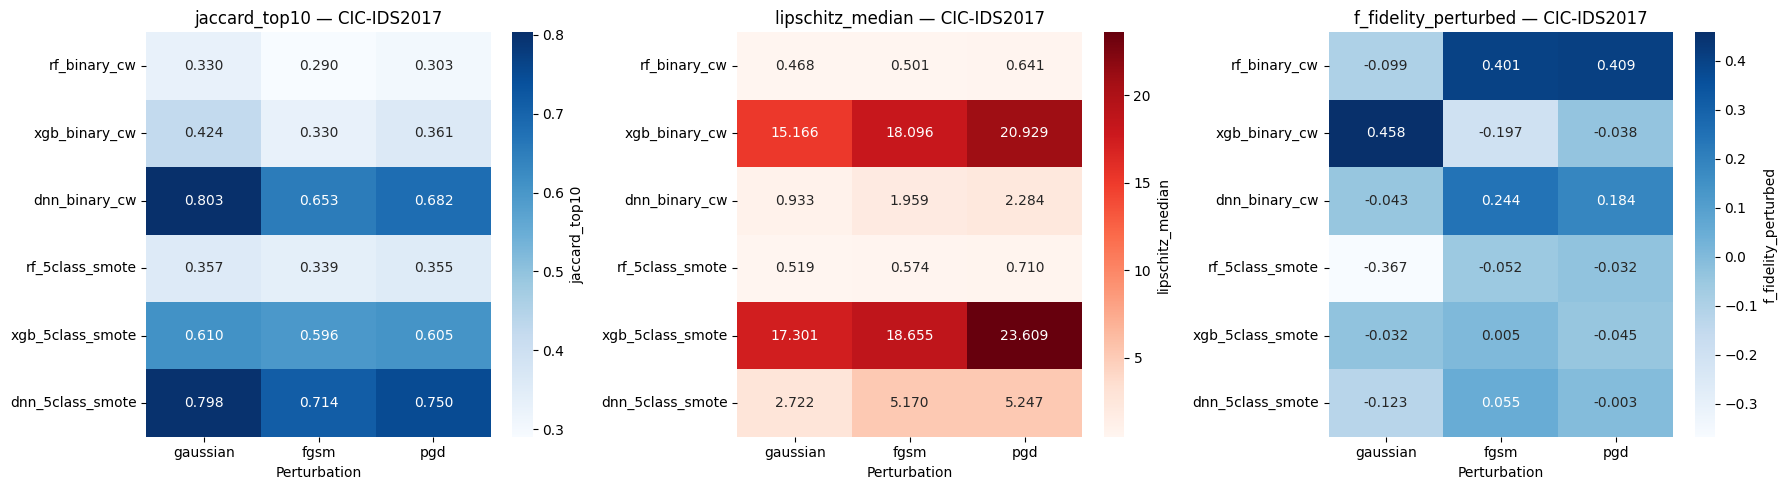

In [12]:
# Visualisation
models = list(CANONICAL.keys())
perts = PERTURBATIONS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['jaccard_top10', 'lipschitz_median', 'f_fidelity_perturbed']):
    mat = np.zeros((len(models), len(perts)))
    for i, m in enumerate(models):
        for j, p in enumerate(perts):
            mat[i, j] = RESULTS[m][p][metric]
    cmap = 'Blues' if metric != 'lipschitz_median' else 'Reds'
    sns.heatmap(mat, annot=True, fmt='.3f', cmap=cmap,
                xticklabels=perts, yticklabels=models, ax=ax, cbar_kws={'label': metric})
    ax.set_title(f'{metric} — CIC-IDS2017'); ax.set_xlabel('Perturbation')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cic_stability_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Commit
os.chdir(REPO)
!git add notebooks/05_cic_stability.ipynb
!git add shap_values/cic_ids2017/stability/stability_metrics.json
!git add results/
!git status --short
!git commit -m 'Notebook 05-CIC: SHAP stability on CIC-IDS2017'
!git push

Refresh index: 100% (86/86), done.
 M notebooks/01_cic_data_exploration.ipynb
 M notebooks/02_cic_train_models.ipynb
 M notebooks/03_cic_calibration.ipynb
 M notebooks/04_cic_shap.ipynb
A  notebooks/05_cic_stability.ipynb
 M notebooks/05_stability_tests.ipynb
 M notebooks/06_shap_agreement.ipynb
 M notebooks/07_scts_v2.ipynb
 M notebooks/08_llm_alerts.ipynb
 M notebooks/09_final_evaluation.ipynb
 M notebooks/10_baselines.ipynb
A  results/baselines/vanilla_rf_cicids2017_5class.pkl
A  results/baselines/vanilla_rf_cicids2017_binary.pkl
A  results/baselines/vanilla_rf_nslkdd_5class.pkl
A  results/baselines/vanilla_rf_nslkdd_binary.pkl
A  results/baselines/vanilla_xgb_cicids2017_5class.pkl
A  results/baselines/vanilla_xgb_cicids2017_binary.pkl
A  results/baselines/vanilla_xgb_nslkdd_5class.pkl
A  results/baselines/vanilla_xgb_nslkdd_binary.pkl
A  results/figures/cic_stability_heatmaps.png
A  results/tables/cic_stability.csv
A  shap_values/cic_ids2017/stability/stability_metrics.json
?? cali

In [14]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/XIDS_Research/xids-research/results/tables/cic_stability.csv')
print('CIC-IDS2017 — Stability metrics')
print('=' * 90)
print(df.to_string(index=False, float_format='%.4f'))
print('=' * 90)

CIC-IDS2017 — Stability metrics
           Model Perturbation  Jaccard@10  Lipschitz (median)  F-Fidelity (perturbed)
    rf_binary_cw     gaussian      0.3299              0.4680                 -0.0986
    rf_binary_cw         fgsm      0.2904              0.5011                  0.4012
    rf_binary_cw          pgd      0.3027              0.6412                  0.4088
   xgb_binary_cw     gaussian      0.4238             15.1662                  0.4582
   xgb_binary_cw         fgsm      0.3300             18.0957                 -0.1973
   xgb_binary_cw          pgd      0.3614             20.9286                 -0.0380
   dnn_binary_cw     gaussian      0.8034              0.9331                 -0.0432
   dnn_binary_cw         fgsm      0.6533              1.9592                  0.2445
   dnn_binary_cw          pgd      0.6821              2.2843                  0.1844
 rf_5class_smote     gaussian      0.3566              0.5190                 -0.3673
 rf_5class_smote      